# Project Foundations for Data Science: FoodHub Data Analysis

**Marks: 60**

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business. 

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [2]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [3]:
# read the data
df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [4]:
df.shape

(1898, 9)

#### Observations:

There are 1898 Rows with 9 columns


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   str    
 3   cuisine_type           1898 non-null   str    
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   str    
 6   rating                 1898 non-null   str    
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), str(4)
memory usage: 196.6 KB


#### Observations:

- The dataset has 1898 rows and 9 columns.
- Columns and their datatypes:
  - order_id: int64
  - customer_id: int64
  - restaurant_name: object (string)
  - cuisine_type: object (string)
  - cost_of_the_order: float64
  - day_of_the_week: object (string)
  - rating: object (string) — stored as string because it contains 'Not given' values instead of NaN
  - food_preparation_time: int64
  - delivery_time: int64
- There are no null values reported by info(), but the `rating` column effectively has missing data encoded as the string 'Not given', which will need to be handled before any numerical analysis on ratings.


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [6]:
print(df.isnull().sum())
df['rating'] = df['rating'].replace('Not given', np.nan).astype(float)
print("\nAfter treatment:")
print(df['rating'].isnull().sum(), "orders have no rating")

order_id                 0
customer_id              0
restaurant_name          0
cuisine_type             0
cost_of_the_order        0
day_of_the_week          0
rating                   0
food_preparation_time    0
delivery_time            0
dtype: int64

After treatment:
736 orders have no rating


#### Observations:

- There we no missing values for any variables
- There were 736 records with no rating. Replaced 'Not Given' in rating with NaN and convert to float



### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [10]:
df.describe().T

# Min, mean, max food preparation time
# print("Min food preparation time:", df['food_preparation_time'].min())
# print("Mean food preparation time:", df['food_preparation_time'].mean())
# print("Max food preparation time:", df['food_preparation_time'].max())

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
rating,1162.0,4.344234e+00,0.741478,3.00,4.00,5.00,5.000000e+00,5.00
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


#### Observations:

Minimum time it takes for food preparation - 20 mins
Average time it takes for food preparation - 27 mins
Maximum time it takes for food preparation - 35 mins



### **Question 5:** How many orders are not rated? [1 mark]

In [11]:
df['rating'].isnull().sum()


np.int64(736)

#### Observations:

736 orders are not rated


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

/var/folders/jm/60365fgd57x77hxl9phhdr1h0000gn/T/ipykernel_4323/1326618331.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, ax=axes[1, 2], palette='Set2')
/var/folders/jm/60365fgd57x77hxl9phhdr1h0000gn/T/ipykernel_4323/1326618331.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='day_of_the_week', data=df, ax=axes[2, 0], palette='Set1')


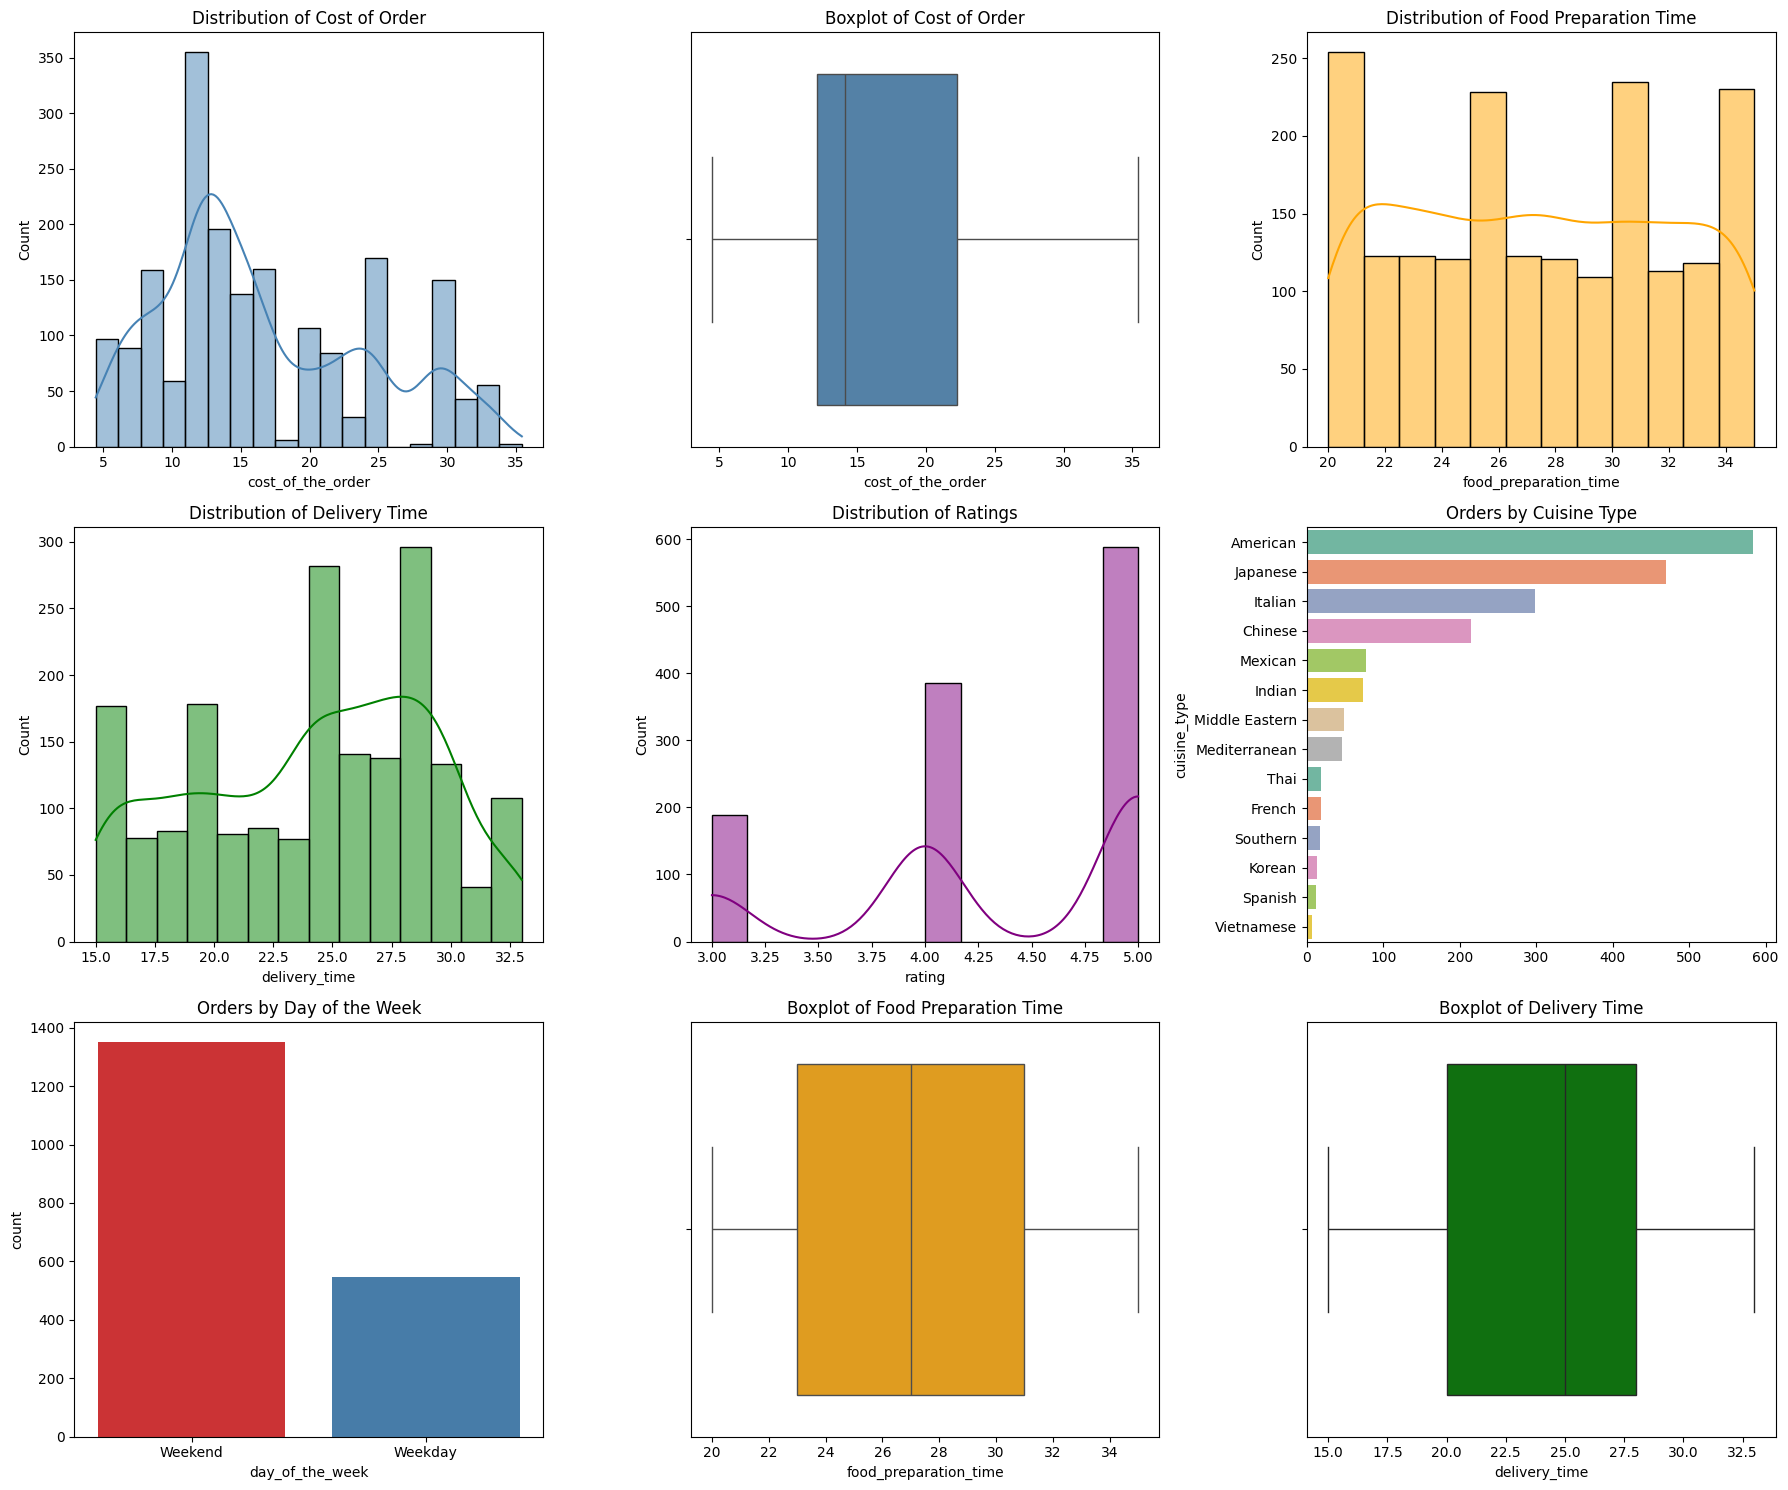

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

sns.histplot(df['cost_of_the_order'], kde=True, ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Distribution of Cost of Order')

sns.boxplot(x=df['cost_of_the_order'], ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Boxplot of Cost of Order')

sns.histplot(df['food_preparation_time'], kde=True, ax=axes[0, 2], color='orange')
axes[0, 2].set_title('Distribution of Food Preparation Time')

sns.histplot(df['delivery_time'], kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Distribution of Delivery Time')

sns.histplot(df['rating'].dropna(), kde=True, ax=axes[1, 1], color='purple')
axes[1, 1].set_title('Distribution of Ratings')

cuisine_counts = df['cuisine_type'].value_counts()
sns.barplot(x=cuisine_counts.values, y=cuisine_counts.index, ax=axes[1, 2], palette='Set2')
axes[1, 2].set_title('Orders by Cuisine Type')

sns.countplot(x='day_of_the_week', data=df, ax=axes[2, 0], palette='Set1')
axes[2, 0].set_title('Orders by Day of the Week')

sns.boxplot(x=df['food_preparation_time'], ax=axes[2, 1], color='orange')
axes[2, 1].set_title('Boxplot of Food Preparation Time')

sns.boxplot(x=df['delivery_time'], ax=axes[2, 2], color='green')
axes[2, 2].set_title('Boxplot of Delivery Time')

plt.tight_layout()
plt.show()


Observations

cost_of_the_order: right-skewed, most orders are in the $10–$20 range
food_preparation_time: roughly uniform between 20–35 minutes
delivery_time: roughly uniform between 15–35 minutes
rating: most given ratings are 4 or 5; many orders are unrated
cuisine_type: American and Japanese are the most ordered cuisines
day_of_the_week: more orders on weekends than weekdays



### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [15]:
df['restaurant_name'].value_counts().head(5)


restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
Name: count, dtype: int64

#### Observations:

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [16]:
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().head(1)


cuisine_type
American    415
Name: count, dtype: int64

#### Observations:
American is the most popular cuisine on weekends with the count of 415


### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [17]:
pct = (df['cost_of_the_order'] > 20).sum() / len(df) * 100
print(f"{pct:.2f}% of orders cost more than $20")


29.24% of orders cost more than $20


#### Observations:
29.24% of orders cost more than $20


### **Question 10**: What is the mean order delivery time? [1 mark]

In [18]:
print(f"Mean delivery time: {df['delivery_time'].mean():.2f} minutes")

Mean delivery time: 24.16 minutes


#### Observations:
Mean delivery time: 24.16 minutes



### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [19]:
df['customer_id'].value_counts().head(3)


customer_id
52832    13
47440    10
83287     9
Name: count, dtype: int64

#### Observations:
customer_id
52832    13
47440    10
83287     9


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


/var/folders/jm/60365fgd57x77hxl9phhdr1h0000gn/T/ipykernel_4323/3016346699.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cost_of_the_order', y='cuisine_type', data=df, ax=axes[0, 2], palette='Set2')
/var/folders/jm/60365fgd57x77hxl9phhdr1h0000gn/T/ipykernel_4323/3016346699.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rating', y='cost_of_the_order', data=df, ax=axes[1, 0], palette='Set1')
/var/folders/jm/60365fgd57x77hxl9phhdr1h0000gn/T/ipykernel_4323/3016346699.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='rati

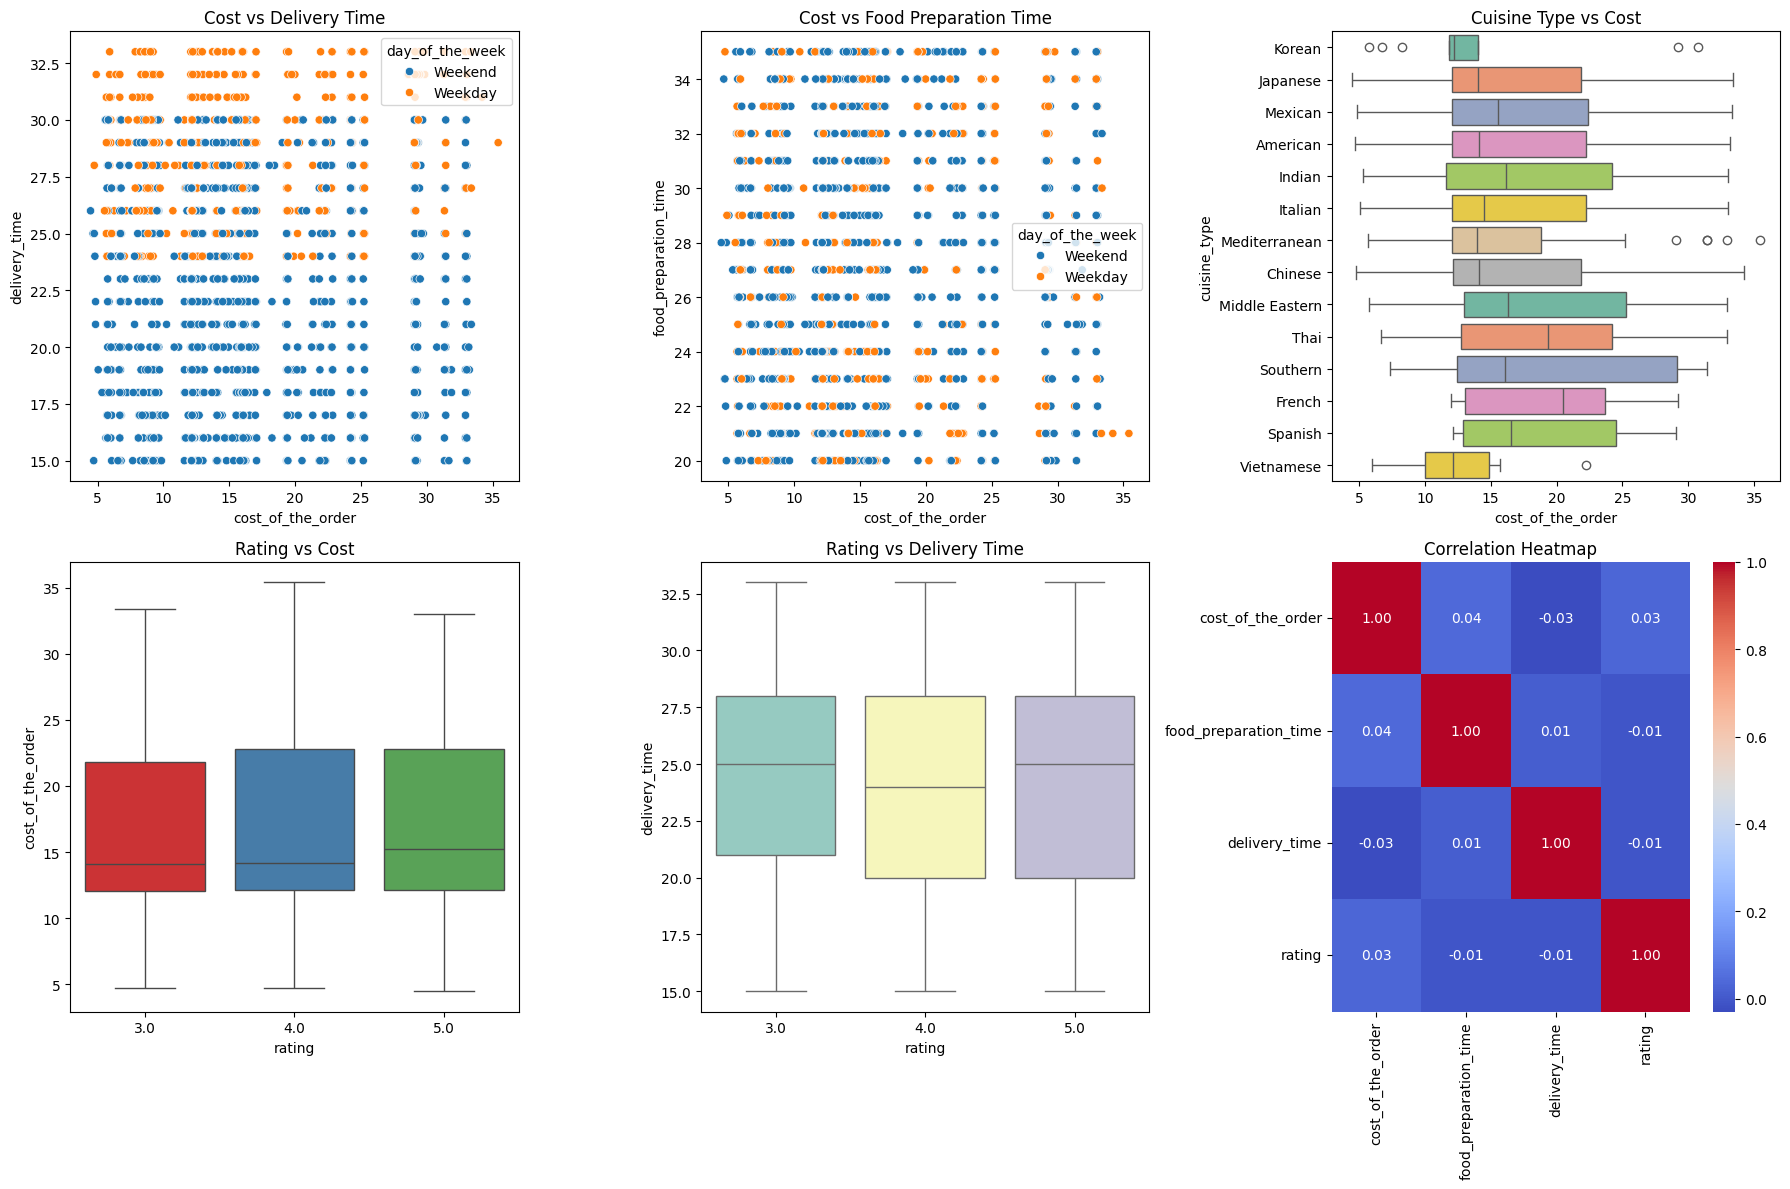

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Cost vs Delivery Time
sns.scatterplot(x='cost_of_the_order', y='delivery_time', hue='day_of_the_week', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Cost vs Delivery Time')

# 2. Cost vs Food Preparation Time
sns.scatterplot(x='cost_of_the_order', y='food_preparation_time', hue='day_of_the_week', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Cost vs Food Preparation Time')

# 3. Cuisine Type vs Cost
sns.boxplot(x='cost_of_the_order', y='cuisine_type', data=df, ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('Cuisine Type vs Cost')

# 4. Rating vs Cost
sns.boxplot(x='rating', y='cost_of_the_order', data=df, ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Rating vs Cost')

# 5. Rating vs Delivery Time
sns.boxplot(x='rating', y='delivery_time', data=df, ax=axes[1, 1], palette='Set3')
axes[1, 1].set_title('Rating vs Delivery Time')

# 6. Heatmap of numerical correlations
corr = df[['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 2])
axes[1, 2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()


### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [21]:
restaurant_stats = df.groupby('restaurant_name')['rating'].agg(['count', 'mean']).reset_index()
restaurant_stats.columns = ['restaurant_name', 'rating_count', 'avg_rating']

promo_restaurants = restaurant_stats[(restaurant_stats['rating_count'] > 50) & (restaurant_stats['avg_rating'] > 4)]
promo_restaurants.sort_values('avg_rating', ascending=False)


,restaurant_name,rating_count,avg_rating
153,The Meatball Shop,84,4.511905
20,Blue Ribbon Fried Chicken,64,4.328125
136,Shake Shack,133,4.278195
21,Blue Ribbon Sushi,73,4.219178


#### Observations:
Restaurant	Rating Count	Avg Rating
The Meatball Shop	84	4.51
Blue Ribbon Fried Chicken	64	4.33
Shake Shack	133	4.28
Blue Ribbon Sushi	73	4.22

### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [23]:
def get_commission(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0

df['commission'] = df['cost_of_the_order'].apply(get_commission)
net_revenue = df['commission'].sum()
print(f"Net revenue generated: ${net_revenue:.2f}")


Net revenue generated: $6166.30


#### Observations:
Net revenue generated: $6166.30


### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [24]:
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
pct = (df['total_time'] > 60).sum() / len(df) * 100
print(f"{pct:.2f}% of orders take more than 60 minutes to deliver")


10.54% of orders take more than 60 minutes to deliver


#### Observations:
10.54% of orders take more than 60 minutes to deliver


### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [25]:
df.groupby('day_of_the_week')['delivery_time'].mean()


day_of_the_week
Weekday    28.340037
Weekend    22.470022
Name: delivery_time, dtype: float64

#### Observations:
Weekday    28.340037
Weekend    22.470022


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
*  ### Conclusions:

**Weekends dominate order volume**: 71.2% of all orders (1,351) are placed on weekends vs. 28.8% (547) on weekdays, indicating FoodHub is primarily a weekend service.

* **American and Japanese cuisines lead demand**: American (584 orders) and Japanese (470 orders) together account for ~55% of all orders. Italian (298) and Chinese (215) follow. Niche cuisines like Korean, Spanish, and Vietnamese have very low order counts.

* **High unrated order rate**: 736 out of 1,898 orders (~38.8%) have no rating, making it difficult to assess customer satisfaction accurately across a large portion of orders.

* **Top-rated cuisines are niche**: Spanish (4.83), Thai (4.67), and Indian (4.54) have the highest average ratings despite low order volumes, suggesting high satisfaction when ordered.

* **Weekday delivery is slower**: Mean delivery time on weekdays is 28.34 minutes vs. 22.47 minutes on weekends — nearly 6 minutes longer, which may be due to traffic or fewer available delivery personnel.

* **10.54% of orders take more than 60 minutes**: A significant portion of orders exceed the 1-hour mark for total delivery time (prep + delivery), which could hurt customer satisfaction.

* **29.24% of orders cost more than $20**: These higher-value orders generate 25% commission, making them disproportionately valuable to revenue.

* **Net revenue is $6,166.30** across all orders from the commission structure.

* **Shake Shack has the most rated orders (133)** among promotional-eligible restaurants, suggesting it is the most engaged customer base.


### Recommendations:

*  ### Recommendations:

* **Incentivize weekday orders**: Offer weekday-only discounts or promotions to balance order volume. Weekdays currently represent less than 30% of orders — boosting this could significantly increase revenue.

* **Promote high-rated niche cuisines**: Spanish, Thai, and Indian cuisines have the highest customer satisfaction but low visibility. Feature them prominently in the app to drive more orders to these restaurants.

* **Reduce the unrated order rate**: Implement post-delivery rating reminders or small incentives (discount vouchers) to increase rating participation from the current 61.2% — more ratings means better restaurant insights.

* **Address slow weekday delivery**: Investigate why weekday delivery takes ~6 minutes longer on average. Consider deploying more delivery personnel on weekdays or optimizing routing.

* **Focus on the 10.54% slow orders**: Identify which restaurants or areas contribute to orders exceeding 60 minutes and work with them to reduce preparation time or reassign delivery routes.

* **Upsell higher-cost orders**: Since orders above $20 earn 25% commission vs. 15% for $5–$20, promoting premium menu items or combo deals could increase revenue without adding more orders.

* **Expand partnership with top 4 promotional restaurants**: The Meatball Shop, Blue Ribbon Fried Chicken, Shake Shack, and Blue Ribbon Sushi all meet the criteria — feature them in advertising to build brand trust and attract new customers.


---